**Jaianm_Shah**
**Enrollment Number 423002**
**Branch: CVT**

In [1]:
import pandas as pd
import numpy as np

from datetime import datetime

%matplotlib inline
pd.set_option('display.max_rows', 500)

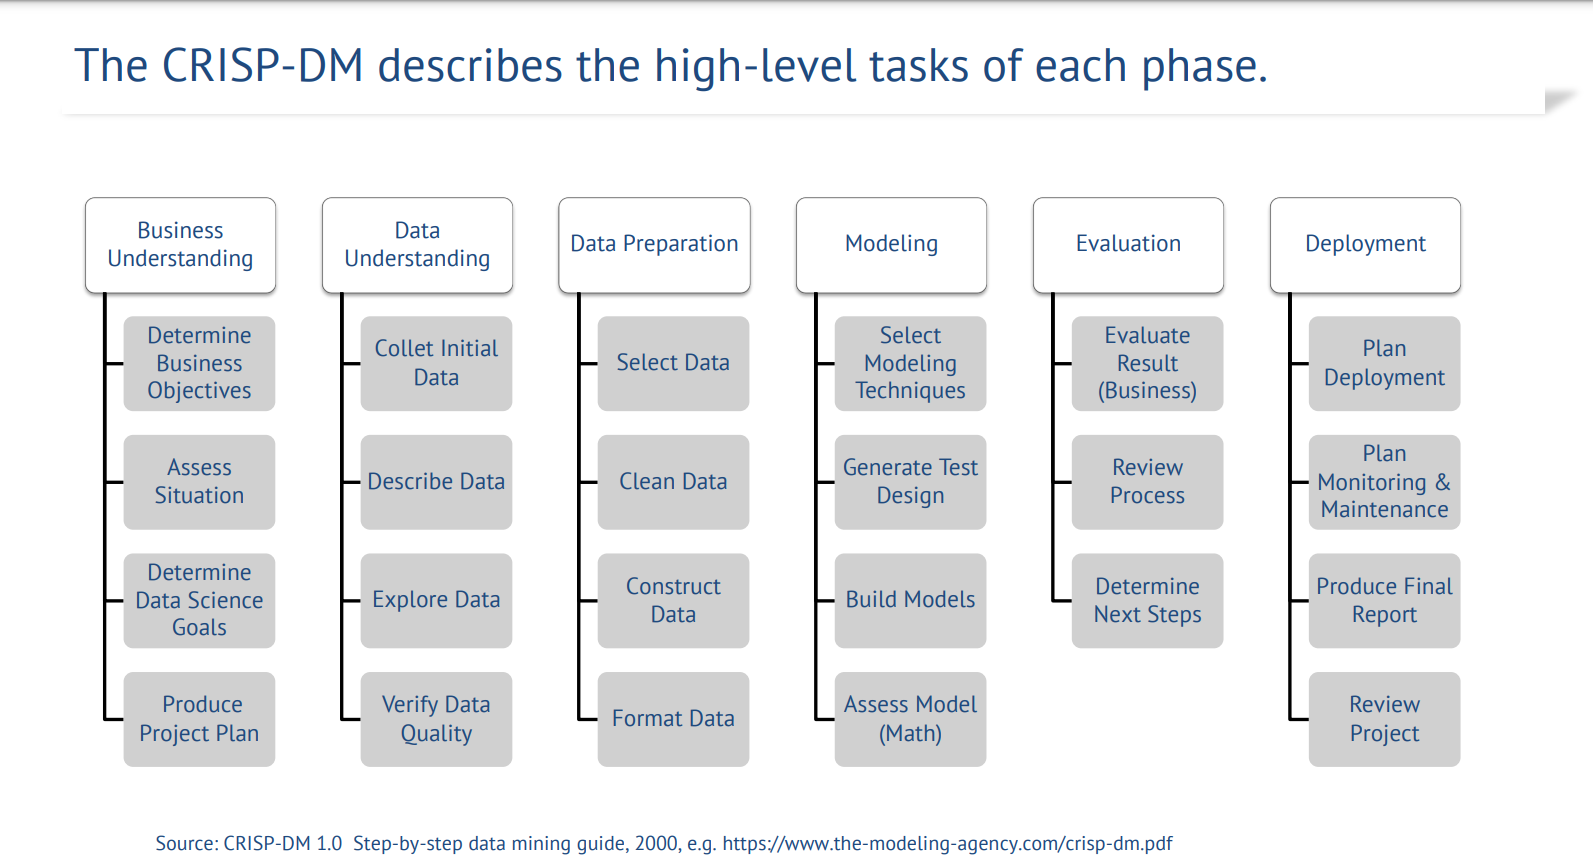

**Data Preparation**


focus is always to understand the final data structure



support each step by visual analytics

**Johns Hopkins GITHUB csv data**

In [2]:
data_path= 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
pd_raw=pd.read_csv(data_path)

In [3]:
pd_raw

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,6/21/22,6/22/22,6/23/22,6/24/22,6/25/22,6/26/22,6/27/22,6/28/22,6/29/22,6/30/22
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,181808,181912,181987,182033,182072,182149,182228,182324,182403,182528
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,277663,277940,278211,278504,278793,279077,279077,279167,280298,280851
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,265993,266006,266015,266025,266030,266038,266049,266062,266073,266087
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,43449,43774,43774,43774,43774,43774,43774,43774,43774,43774
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,99761,99761,99761,99761,99761,99761,99761,101320,101320,101320
5,NaN,Antarctica,-71.949900,23.347000,0,0,0,0,0,0,...,11,11,11,11,11,11,11,11,11,11
6,NaN,Antigua and Barbuda,17.060800,-61.796400,0,0,0,0,0,0,...,8581,8590,8590,8625,8625,8625,8625,8625,8625,8641
7,NaN,Argentina,-38.416100,-63.616700,0,0,0,0,0,0,...,9341492,9341492,9341492,9341492,9341492,9367172,9367172,9367172,9367172,9367172
8,NaN,Armenia,40.069100,45.038200,0,0,0,0,0,0,...,423104,423104,423104,423104,423104,423104,423243,423243,423243,423243
9,Australian Capital Territory,Australia,-35.473500,149.012400,0,0,0,0,0,0,...,148996,150123,151113,152199,153012,153939,155047,156472,157678,158826


In [4]:
pd_raw.columns[4:]

Index(['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       '1/28/20', '1/29/20', '1/30/20', '1/31/20',
       ...
       '6/21/22', '6/22/22', '6/23/22', '6/24/22', '6/25/22', '6/26/22',
       '6/27/22', '6/28/22', '6/29/22', '6/30/22'],
      dtype='object', length=891)

In [5]:
time_idx=pd_raw.columns[4:]

In [6]:
df_plot=pd.DataFrame({
    'date':time_idx})
df_plot.head()

,date
0,1/22/20
1,1/23/20
2,1/24/20
3,1/25/20
4,1/26/20


In [7]:
pd_raw['Country/Region'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Diamond Princess', 'Djibouti', 'Dominica', 'Dominican Republic',
       'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea',
       'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Grenada', 'Gua

In [8]:
len(pd_raw['Country/Region'].unique())

199

In [9]:
pd_raw['Country/Region']

0                           Afghanistan
1                               Albania
2                               Algeria
3                               Andorra
4                                Angola
5                            Antarctica
6                   Antigua and Barbuda
7                             Argentina
8                               Armenia
9                             Australia
10                            Australia
11                            Australia
12                            Australia
13                            Australia
14                            Australia
15                            Australia
16                            Australia
17                              Austria
18                           Azerbaijan
19                              Bahamas
20                              Bahrain
21                           Bangladesh
22                             Barbados
23                              Belarus
24                              Belgium


In [10]:
pd_raw[pd_raw['Country/Region']=='US']

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,6/21/22,6/22/22,6/23/22,6/24/22,6/25/22,6/26/22,6/27/22,6/28/22,6/29/22,6/30/22
257,NaN,US,40.0,-100.0,1,1,2,2,5,5,...,86535750,86719815,86867972,86984462,87024491,87043484,87169559,87296327,87490815,87627486


In [11]:
pd_raw[pd_raw['Country/Region']=='Germany'].iloc[:,4::].sum(axis=0)[0:4]

1/22/20    0
1/23/20    0
1/24/20    0
1/25/20    0
dtype: int64

In [12]:
country_list=['Italy',
              'US',
              'Spain',
              'Germany'
             ]

In [13]:
for each in country_list:
    df_plot[each]=np.array(pd_raw[pd_raw['Country/Region']==each].iloc[:,4::].sum(axis=0))

In [14]:
df_plot

,date,Italy,US,Spain,Germany
0,1/22/20,0,1,0,0
1,1/23/20,0,1,0,0
2,1/24/20,0,2,0,0
3,1/25/20,0,2,0,0
4,1/26/20,0,5,0,0
...,...,...,...,...,...
886,6/26/22,18234242,87043484,12681820,27771911
887,6/27/22,18259261,87169559,12681820,27914240
888,6/28/22,18343422,87296327,12734038,28048190
889,6/29/22,18438877,87490815,12734038,28180861


<AxesSubplot:xlabel='date'>

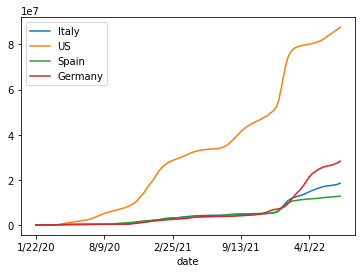

In [15]:
%matplotlib inline
df_plot.set_index('date').plot()

**Data Type Date**


In [16]:
type(df_plot.date[0])

str

In [17]:
df_plot.head()

,date,Italy,US,Spain,Germany
0,1/22/20,0,1,0,0
1,1/23/20,0,1,0,0
2,1/24/20,0,2,0,0
3,1/25/20,0,2,0,0
4,1/26/20,0,5,0,0


In [18]:
from datetime import datetime

In [19]:
df_plot.date[0]

'1/22/20'

In [20]:
datetime.strptime(df_plot.date[0],"%m/%d/%y")

datetime.datetime(2020, 1, 22, 0, 0)

In [21]:
time_idx=[datetime.strptime( each,"%m/%d/%y") for each in df_plot.date] # convert to datetime

In [22]:
time_idx[0:5]

[datetime.datetime(2020, 1, 22, 0, 0),
 datetime.datetime(2020, 1, 23, 0, 0),
 datetime.datetime(2020, 1, 24, 0, 0),
 datetime.datetime(2020, 1, 25, 0, 0),
 datetime.datetime(2020, 1, 26, 0, 0)]

In [23]:
time_str=[each.strftime('%Y-%m-%d') for each in time_idx] # convert back to date ISO norm (str)

In [24]:
time_str

['2020-01-22',
 '2020-01-23',
 '2020-01-24',
 '2020-01-25',
 '2020-01-26',
 '2020-01-27',
 '2020-01-28',
 '2020-01-29',
 '2020-01-30',
 '2020-01-31',
 '2020-02-01',
 '2020-02-02',
 '2020-02-03',
 '2020-02-04',
 '2020-02-05',
 '2020-02-06',
 '2020-02-07',
 '2020-02-08',
 '2020-02-09',
 '2020-02-10',
 '2020-02-11',
 '2020-02-12',
 '2020-02-13',
 '2020-02-14',
 '2020-02-15',
 '2020-02-16',
 '2020-02-17',
 '2020-02-18',
 '2020-02-19',
 '2020-02-20',
 '2020-02-21',
 '2020-02-22',
 '2020-02-23',
 '2020-02-24',
 '2020-02-25',
 '2020-02-26',
 '2020-02-27',
 '2020-02-28',
 '2020-02-29',
 '2020-03-01',
 '2020-03-02',
 '2020-03-03',
 '2020-03-04',
 '2020-03-05',
 '2020-03-06',
 '2020-03-07',
 '2020-03-08',
 '2020-03-09',
 '2020-03-10',
 '2020-03-11',
 '2020-03-12',
 '2020-03-13',
 '2020-03-14',
 '2020-03-15',
 '2020-03-16',
 '2020-03-17',
 '2020-03-18',
 '2020-03-19',
 '2020-03-20',
 '2020-03-21',
 '2020-03-22',
 '2020-03-23',
 '2020-03-24',
 '2020-03-25',
 '2020-03-26',
 '2020-03-27',
 '2020-03-

In [25]:
time_str[0:6]

['2020-01-22',
 '2020-01-23',
 '2020-01-24',
 '2020-01-25',
 '2020-01-26',
 '2020-01-27']

In [26]:
df_plot['date']=time_idx
type(df_plot['date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [27]:
df_plot.head()

,date,Italy,US,Spain,Germany
0,2020-01-22,0,1,0,0
1,2020-01-23,0,1,0,0
2,2020-01-24,0,2,0,0
3,2020-01-25,0,2,0,0
4,2020-01-26,0,5,0,0


In [28]:
df_plot.to_csv("Covid Data.csv",sep=';')

**Relational data model - defining a primary key**

In the relational model of databases, a primary key is a specific choice of a minimal set of attributes (columns) that uniquely specify a tuple (row) in a relation (table) (source: wiki)

**A primary key’s main features are:**

It must contain a unique value for each row of data.

It cannot contain null values.

In [29]:
data_path= 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
pd_raw=pd.read_csv(data_path)
pd_raw.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,6/21/22,6/22/22,6/23/22,6/24/22,6/25/22,6/26/22,6/27/22,6/28/22,6/29/22,6/30/22
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,181808,181912,181987,182033,182072,182149,182228,182324,182403,182528
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,277663,277940,278211,278504,278793,279077,279077,279167,280298,280851
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,265993,266006,266015,266025,266030,266038,266049,266062,266073,266087
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,43449,43774,43774,43774,43774,43774,43774,43774,43774,43774
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,99761,99761,99761,99761,99761,99761,99761,101320,101320,101320


In [30]:
pd_data_base=pd_raw.rename(columns={'Country/Region':'country',
                      'Province/State':'state'})

In [31]:
pd_data_base=pd_data_base.drop(['Lat','Long'],axis=1)
pd_data_base.head()

,state,country,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,6/21/22,6/22/22,6/23/22,6/24/22,6/25/22,6/26/22,6/27/22,6/28/22,6/29/22,6/30/22
0,NaN,Afghanistan,0,0,0,0,0,0,0,0,...,181808,181912,181987,182033,182072,182149,182228,182324,182403,182528
1,NaN,Albania,0,0,0,0,0,0,0,0,...,277663,277940,278211,278504,278793,279077,279077,279167,280298,280851
2,NaN,Algeria,0,0,0,0,0,0,0,0,...,265993,266006,266015,266025,266030,266038,266049,266062,266073,266087
3,NaN,Andorra,0,0,0,0,0,0,0,0,...,43449,43774,43774,43774,43774,43774,43774,43774,43774,43774
4,NaN,Angola,0,0,0,0,0,0,0,0,...,99761,99761,99761,99761,99761,99761,99761,101320,101320,101320


In [32]:
pd_data_base.set_index(['state', 'country'])

1/22/20  \
state                                        country                                     
NaN                                          Afghanistan                             0   
                                             Albania                                 0   
                                             Algeria                                 0   
                                             Andorra                                 0   
                                             Angola                                  0   
                                             Antarctica                              0   
                                             Antigua and Barbuda                     0   
                                             Argentina                               0   
                                             Armenia                                 0   
Australian Capital Territory                 Australia                               0   
New South Wales                              Australia                               0   
Northern Territory                           Australia                               0   
Queensland                                   Australia                               0   
South Australia                              Australia                               0   
Tasmania                                     Australia                               0   
Victoria                                     Australia                               0   
Western Australia                            Australia                               0   
NaN                                          Austria                                 0   
                                             Azerbaijan                              0   
                                             Bahamas                                 0   
                                             Bahrain                                 0   
                                             Bangladesh                              0   
                                             Barbados                                0   
                                             Belarus                                 0   
                                             Belgium                                 0   
                                             Belize                                  0   
                                             Benin                                   0   
                                             Bhutan                                  0   
                                             Bolivia                                 0   
                                             Bosnia and Herzegovina                  0   
                                             Botswana                                0   
                                             Brazil                                  0   
                                             Brunei                                  0   
                                             Bulgaria                                0   
                                             Burkina Faso                            0   
                                             Burma                                   0   
                                             Burundi                                 0   
                                             Cabo Verde                              0   
                                             Cambodia                                0   
                                             Cameroon                                0   
Alberta                                      Canada                                  0   
British Columbia                             Canada                                  0   
Diamond Princess                             Canada                                  0   
Grand Princess               

In [33]:
test_pd=pd_data_base.set_index(['state', 'country']).T

In [34]:
test_pd.columns

MultiIndex([(                           nan,          'Afghanistan'),
            (                           nan,              'Albania'),
            (                           nan,              'Algeria'),
            (                           nan,              'Andorra'),
            (                           nan,               'Angola'),
            (                           nan,           'Antarctica'),
            (                           nan,  'Antigua and Barbuda'),
            (                           nan,            'Argentina'),
            (                           nan,              'Armenia'),
            ('Australian Capital Territory',            'Australia'),
            ...
            (                           nan,              'Uruguay'),
            (                           nan,           'Uzbekistan'),
            (                           nan,              'Vanuatu'),
            (                           nan,            'Venezuela'),
    

In [35]:
pd_relational_model= test_pd.stack(level=[0,1]).reset_index()
pd_relational_model.rename({'level_0':'date',0:'confirmed'}, axis=1, inplace=True)
pd_relational_model

,date,state,country,confirmed
0,1/22/20,NaN,Afghanistan,0.0
1,1/22/20,NaN,Albania,0.0
2,1/22/20,NaN,Algeria,0.0
3,1/22/20,NaN,Andorra,0.0
4,1/22/20,NaN,Angola,0.0
...,...,...,...,...
253930,6/30/22,Western Australia,Australia,908851.0
253931,6/30/22,Xinjiang,China,1008.0
253932,6/30/22,Yukon,Canada,4476.0
253933,6/30/22,Yunnan,China,2174.0


In [36]:
pd_relational_model['date']=pd_relational_model.date.astype('datetime64[ns]')

In [37]:
pd_relational_model.dtypes

date         datetime64[ns]
state                object
country              object
confirmed           float64
dtype: object

In [38]:
df_plot.to_csv("Covid_Data.csv",sep=';',index=False)